# Noise Model: Calibration Floors & Outlier Robustness

Real photometric uncertainties are almost always **underestimated**.
Calibration systematics, model inadequacy, aperture errors, and
occasional catastrophic measurements conspire to make the true noise
larger than the reported uncertainties.

When noise is underestimated, the chi-squared term dominates the
posterior and it collapses to an overconfident point estimate ---
defeating the purpose of sophisticated inference machinery like geoVI.

This notebook demonstrates diffsed's **NIFTy-native noise model**,
which follows Information Field Theory (IFT) principles: noise
parameters are part of the generative model and jointly inferred
with the signal. We show:

1. **The problem**: underestimated noise causes posterior collapse
2. **Calibration floor**: `noise_frac_cal` adds a fractional
   uncertainty in quadrature, with a log-determinant penalty
   preventing the trivial solution
3. **Student-t outlier robustness**: `noise_dof=Fixed(2.0)` naturally
   downweights catastrophic data points without explicit masking
4. **Combined model**: calibration floor + Student-t on real-like data

### NIFTy Likelihood Classes Used

| Setting | NIFTy Likelihood | Energy |
|---------|-----------------|--------|
| Default (no noise params) | `jft.Gaussian` | $\frac{1}{2}\chi^2$ |
| `noise_frac_cal` free | `jft.VariableCovarianceGaussian` | $\frac{1}{2}\chi^2_\mathrm{eff} + \sum\log\sigma_\mathrm{eff}$ |
| `noise_frac_cal` + `noise_dof` | `jft.VariableCovarianceStudentT` | $\frac{\nu+1}{2}\sum\log(1+r^2/\nu) + \sum\log\sigma_\mathrm{eff}$ |

### References

- Ensslin et al. (2009) --- Information Field Theory
- Edenhofer et al. (2024) --- NIFTy.re
- Johnson et al. (2021) --- Prospector noise model
- Alsing et al. (2022) --- Hierarchical noise model, Student-t($\nu$=2)
- Bellstedt et al. (2020) --- Band-dependent calibration floors
- Hogg, Bovy & Lang (2010) --- Outlier mixture model

In [1]:
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

import os
import sys

sys.path.insert(0, ".")
from _plot_style import COLORS, setup_style

setup_style()
os.makedirs("notebook_figures", exist_ok=True)

from diffsed import (
    Fitter,
    Fixed,
    Model,
    ParamSpec,
    Uniform,
    load_filter_set,
    load_ssp_data,
)
from diffsed.noise import compute_effective_noise, variable_noise_hamiltonian

In [2]:
ssp_data = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
print(f"SSP: {len(ssp_data.ssp_lgmet)} Z x {len(ssp_data.ssp_lg_age_gyr)} ages")

SDSS_WAVE = jnp.array([3551.0, 4686.0, 6166.0, 7480.0, 8932.0])
BAND_NAMES = ["u", "g", "r", "i", "z"]

SSP: 15 Z x 93 ages


## 1. The Problem: Posterior Collapse with Underestimated Noise

We generate a mock galaxy with SNR=20 photometry, then fit it with
**artificially halved** noise (simulating underestimated uncertainties).
Without a noise model, the posterior collapses.

In [3]:
# --- Generate truth ---
spec_true = ParamSpec(
    sfh_dpl_alpha=Uniform(0.5, 3.0),
    sfh_dpl_beta=Uniform(0.5, 3.0),
    sfh_dpl_tau_gyr=Uniform(0.5, 13.0),
    sfh_dpl_log_peak_sfr=Uniform(-1.0, 2.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Fixed(0.3),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="dpl",
)
model_true = Model(spec_true, ssp_data, filters=filters)

key = jax.random.PRNGKey(2025)
true_params = spec_true.sample(key)
mock = model_true.mock(true_params, snr=20.0, key=key)

# Create "underestimated" noise: halve the true noise
noise_correct = mock.noise
noise_underestimated = mock.noise * 0.5

print(f"True noise:         {np.array(noise_correct)}")
print(f"Underestimated:     {np.array(noise_underestimated)}")
print(f"Ratio (should be 2): {np.mean(np.array(noise_correct / noise_underestimated)):.1f}")

W0318 15:28:34.816611 9405943 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


True noise:         [6.58611739e-29 2.82924881e-28 5.37068235e-28 7.16885934e-28
 9.21592930e-28]
Underestimated:     [3.29305870e-29 1.41462440e-28 2.68534118e-28 3.58442967e-28
 4.60796465e-28]
Ratio (should be 2): 2.0


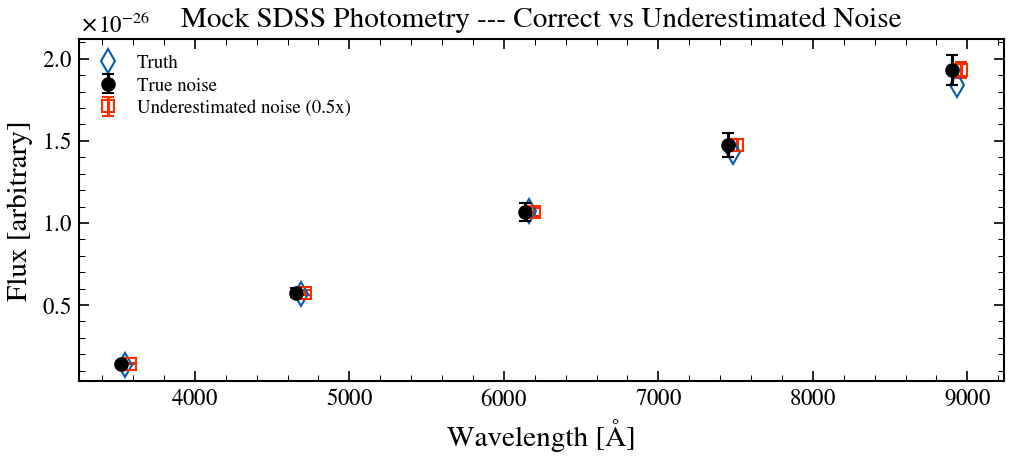

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.errorbar(
    SDSS_WAVE - 30,
    mock.flux_obs,
    yerr=noise_correct,
    fmt="o",
    color="k",
    label="True noise",
    capsize=3,
    zorder=3,
)
ax.errorbar(
    SDSS_WAVE + 30,
    mock.flux_obs,
    yerr=noise_underestimated,
    fmt="s",
    color="C3",
    mfc="none",
    label="Underestimated noise (0.5x)",
    capsize=3,
    zorder=2,
)
ax.plot(SDSS_WAVE, mock.flux_true, "d", ms=8, mfc="none", color="C0", label="Truth")
ax.set_xlabel("Wavelength [\u00c5]")
ax.set_ylabel("Flux [arbitrary]")
ax.set_title("Mock SDSS Photometry --- Correct vs Underestimated Noise")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("notebook_figures/11_noise_model_fig01.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Fit Without Noise Model (Posterior Collapse)

With underestimated noise and no noise model, the chi-squared is
inflated and the posterior becomes very narrow.

In [5]:
# Fit with correct noise (baseline)
fitter_correct = Fitter(model_true, mock.flux_obs, noise_correct)
result_correct = fitter_correct.run("map", n_steps=500, key=jax.random.PRNGKey(0))

# Fit with underestimated noise (no noise model)
fitter_under = Fitter(model_true, mock.flux_obs, noise_underestimated)
result_under = fitter_under.run("map", n_steps=500, key=jax.random.PRNGKey(0))

# Chi-squared comparison
pred_correct = model_true.predict_photometry(result_correct.params)
pred_under = model_true.predict_photometry(result_under.params)

chi2_correct = float(jnp.sum(((mock.flux_obs - pred_correct) / noise_correct) ** 2))
chi2_under = float(jnp.sum(((mock.flux_obs - pred_under) / noise_underestimated) ** 2))

print(f"chi2/dof (correct noise):       {chi2_correct / 5:.1f}")
print(f"chi2/dof (underestimated noise): {chi2_under / 5:.1f}")
print("\nWith underestimated noise, chi2/dof is inflated,")
print("driving the posterior toward the MAP with zero uncertainty.")

  Step     0/500: loss = 889.8040
  Step   200/500: loss = 3.3482
  Step   400/500: loss = 0.9915
  Step   499/500: loss = 0.9366
  MAP (ADAM) complete in 0.2s, 500 steps
  Step     0/500: loss = 3559.2159


  Step   200/500: loss = 13.3929
  Step   400/500: loss = 3.9661
  Step   499/500: loss = 3.7466
  MAP (ADAM) complete in 0.2s, 500 steps
chi2/dof (correct noise):       0.4
chi2/dof (underestimated noise): 1.5

With underestimated noise, chi2/dof is inflated,
driving the posterior toward the MAP with zero uncertainty.


## 3. The Calibration Floor: `noise_frac_cal`

The effective noise is:

$$\sigma^2_{\mathrm{eff},k} = \sigma^2_{\mathrm{obs},k} + (f_\mathrm{cal} \cdot |m_k|)^2$$

where $f_\mathrm{cal}$ is a fractional calibration uncertainty inferred
from data. The full likelihood includes a **log-determinant penalty**
$\sum_k \log \sigma_{\mathrm{eff},k}$ that prevents the trivial solution
$\sigma \to \infty$.

This is implemented via NIFTy's `VariableCovarianceGaussian` likelihood.

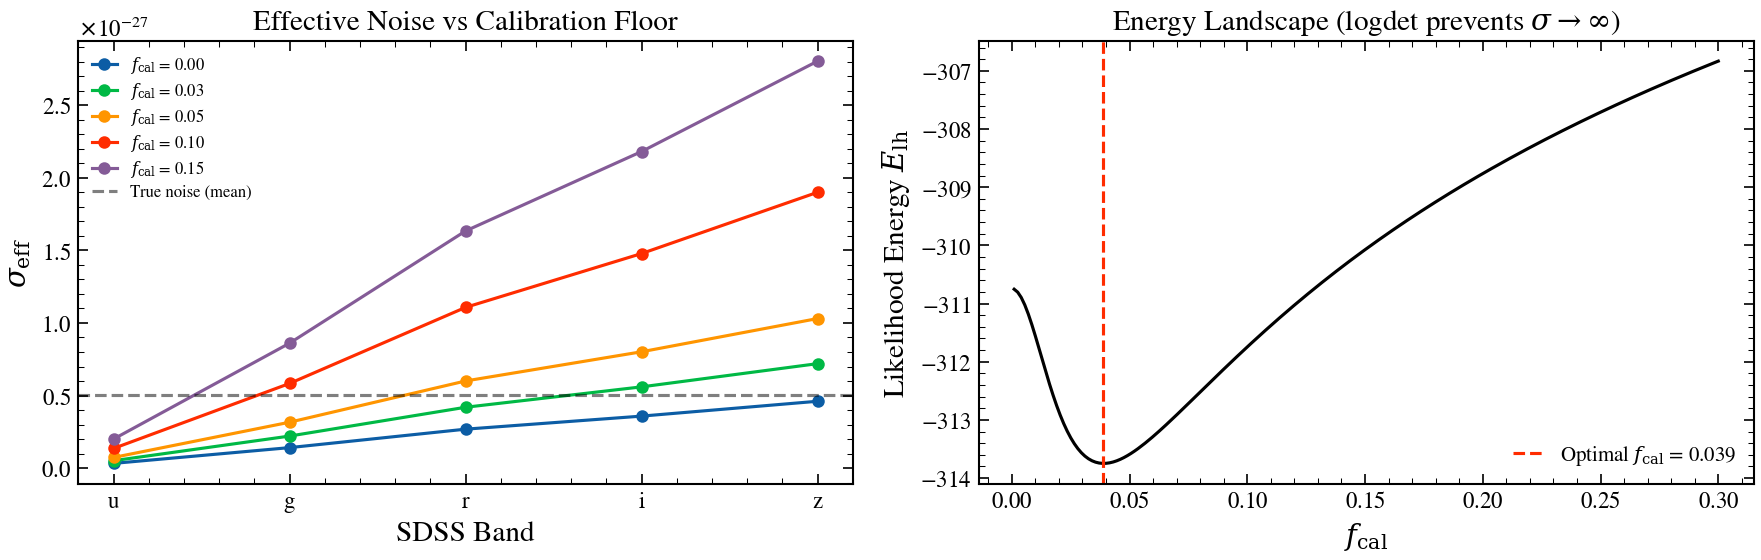

In [6]:
# --- Visualize effective noise for different f_cal values ---
model_flux = mock.flux_true
f_cal_values = [0.0, 0.03, 0.05, 0.10, 0.15]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: effective noise vs band
ax = axes[0]
for f_cal in f_cal_values:
    sigma_eff = compute_effective_noise(noise_underestimated, model_flux, f_cal)
    label = f"$f_{{\\mathrm{{cal}}}}$ = {f_cal:.2f}"
    ax.plot(BAND_NAMES, np.array(sigma_eff), "o-", label=label, ms=5)

ax.axhline(
    float(jnp.mean(noise_correct)),
    color="k",
    ls="--",
    alpha=0.5,
    label="True noise (mean)",
)
ax.set_xlabel("SDSS Band")
ax.set_ylabel("$\\sigma_\\mathrm{eff}$")
ax.set_title("Effective Noise vs Calibration Floor")
ax.legend(fontsize=8)

# Right: energy landscape vs f_cal
ax = axes[1]
f_cal_grid = np.linspace(0.001, 0.3, 200)
energies = [
    float(variable_noise_hamiltonian(mock.flux_obs, noise_underestimated, model_flux, f))
    for f in f_cal_grid
]

ax.plot(f_cal_grid, energies, "k-", lw=1.5)
ax.axvline(
    f_cal_grid[np.argmin(energies)],
    color="C3",
    ls="--",
    label=f"Optimal $f_{{\\mathrm{{cal}}}}$ = {f_cal_grid[np.argmin(energies)]:.3f}",
)
ax.set_xlabel("$f_\\mathrm{cal}$")
ax.set_ylabel("Likelihood Energy $E_{\\mathrm{lh}}$")
ax.set_title("Energy Landscape (logdet prevents $\\sigma \\to \\infty$)")
ax.legend()

plt.tight_layout()
plt.savefig("notebook_figures/11_noise_model_fig02.png", dpi=150, bbox_inches="tight")
plt.show()

The energy has a **finite minimum** --- the log-determinant term
$\sum \log \sigma_\mathrm{eff}$ prevents $f_\mathrm{cal} \to \infty$.
This is the key insight from Information Field Theory: encoding noise
structure in the likelihood creates a self-consistent balance
(Knollmuller & Ensslin 2019).

## 4. Fit With Noise Model: Wider, Honest Posteriors

Now we fit the same underestimated-noise data, but with
`noise_frac_cal=Uniform(0.01, 0.2)` enabled. The fitter automatically
switches to `jft.VariableCovarianceGaussian`.

In [7]:
# Spec with noise model
spec_noise = ParamSpec(
    sfh_dpl_alpha=Uniform(0.5, 3.0),
    sfh_dpl_beta=Uniform(0.5, 3.0),
    sfh_dpl_tau_gyr=Uniform(0.5, 13.0),
    sfh_dpl_log_peak_sfr=Uniform(-1.0, 2.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Fixed(0.3),
    dust_slope=Fixed(-0.7),
    noise_frac_cal=Uniform(0.01, 0.2),
    redshift=Fixed(0.1),
    mean_sfh_type="dpl",
)
model_noise = Model(spec_noise, ssp_data, filters=filters)
print(f"Free parameters: {spec_noise.n_free} (includes noise_frac_cal)")

# Fit with EVI
fitter_noise = Fitter(model_noise, mock.flux_obs, noise_underestimated)
result_noise = fitter_noise.run(
    "evi", n_iterations=30, n_samples=3, n_posterior_samples=500, key=jax.random.PRNGKey(1)
)

print(f"\nRecovered noise_frac_cal: {result_noise.params.get('noise_frac_cal', 'N/A'):.3f}")
print(f"Wall time: {result_noise.wall_time_s:.1f}s")

Free parameters: 7 (includes noise_frac_cal)


EVI (JIT): 7 params, 5 data points, 30 iterations, 3 samples/iter, 5 seeds


  Seed 1/5: H=20242.1, 12 iters
  Seed 2/5: H=685.4, 30 iters
  Seed 3/5: H=16174.8, 13 iters
  Seed 4/5: H=14993.5, 11 iters
  Seed 5/5: H=12015.1, 24 iters
  Drawing 500 posterior samples (JIT CG)...


<local>/Projects/diffsed/src/diffsed/fitter.py:987: UserWarning: Seeds disagree: H = 12822.2 ± 6617.6 (CV=52%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_evi_jit(key=key, init_from=init_from, **kwargs)


  EVI (JIT) complete in 5.6s, 30/30 iterations, 500 posterior samples

Recovered noise_frac_cal: 0.127
Wall time: 5.6s


<local>/Projects/diffsed/src/diffsed/fitter.py:987: UserWarning: Poor fit: chi2/dof=710.9 (expected ~1)
  return self._run_evi_jit(key=key, init_from=init_from, **kwargs)


### Compare posteriors: with vs without noise model

In [8]:
# Also fit without noise model for comparison (same underestimated noise)
spec_nonoise = ParamSpec(
    sfh_dpl_alpha=Uniform(0.5, 3.0),
    sfh_dpl_beta=Uniform(0.5, 3.0),
    sfh_dpl_tau_gyr=Uniform(0.5, 13.0),
    sfh_dpl_log_peak_sfr=Uniform(-1.0, 2.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Fixed(0.3),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="dpl",
)
model_nonoise = Model(spec_nonoise, ssp_data, filters=filters)

fitter_nonoise = Fitter(model_nonoise, mock.flux_obs, noise_underestimated)
result_nonoise = fitter_nonoise.run(
    "evi", n_iterations=30, n_samples=3, n_posterior_samples=500, key=jax.random.PRNGKey(1)
)

EVI (JIT): 6 params, 5 data points, 30 iterations, 3 samples/iter, 5 seeds


  Seed 1/5: H=14.4, 15 iters
  Seed 2/5: H=98.8, 30 iters
  Seed 3/5: H=11.4, 6 iters
  Seed 4/5: H=17.0, 29 iters


  Seed 5/5: H=19.7, 30 iters
  Drawing 500 posterior samples (JIT CG)...


<local>/Projects/diffsed/src/diffsed/fitter.py:987: UserWarning: Seeds disagree: H = 32.3 ± 33.4 (CV=103%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_evi_jit(key=key, init_from=init_from, **kwargs)


  EVI (JIT) complete in 4.6s, 6/30 iterations, 500 posterior samples


<local>/Projects/diffsed/src/diffsed/fitter.py:987: UserWarning: Poor fit: chi2/dof=6.8 (expected ~1)
  return self._run_evi_jit(key=key, init_from=init_from, **kwargs)


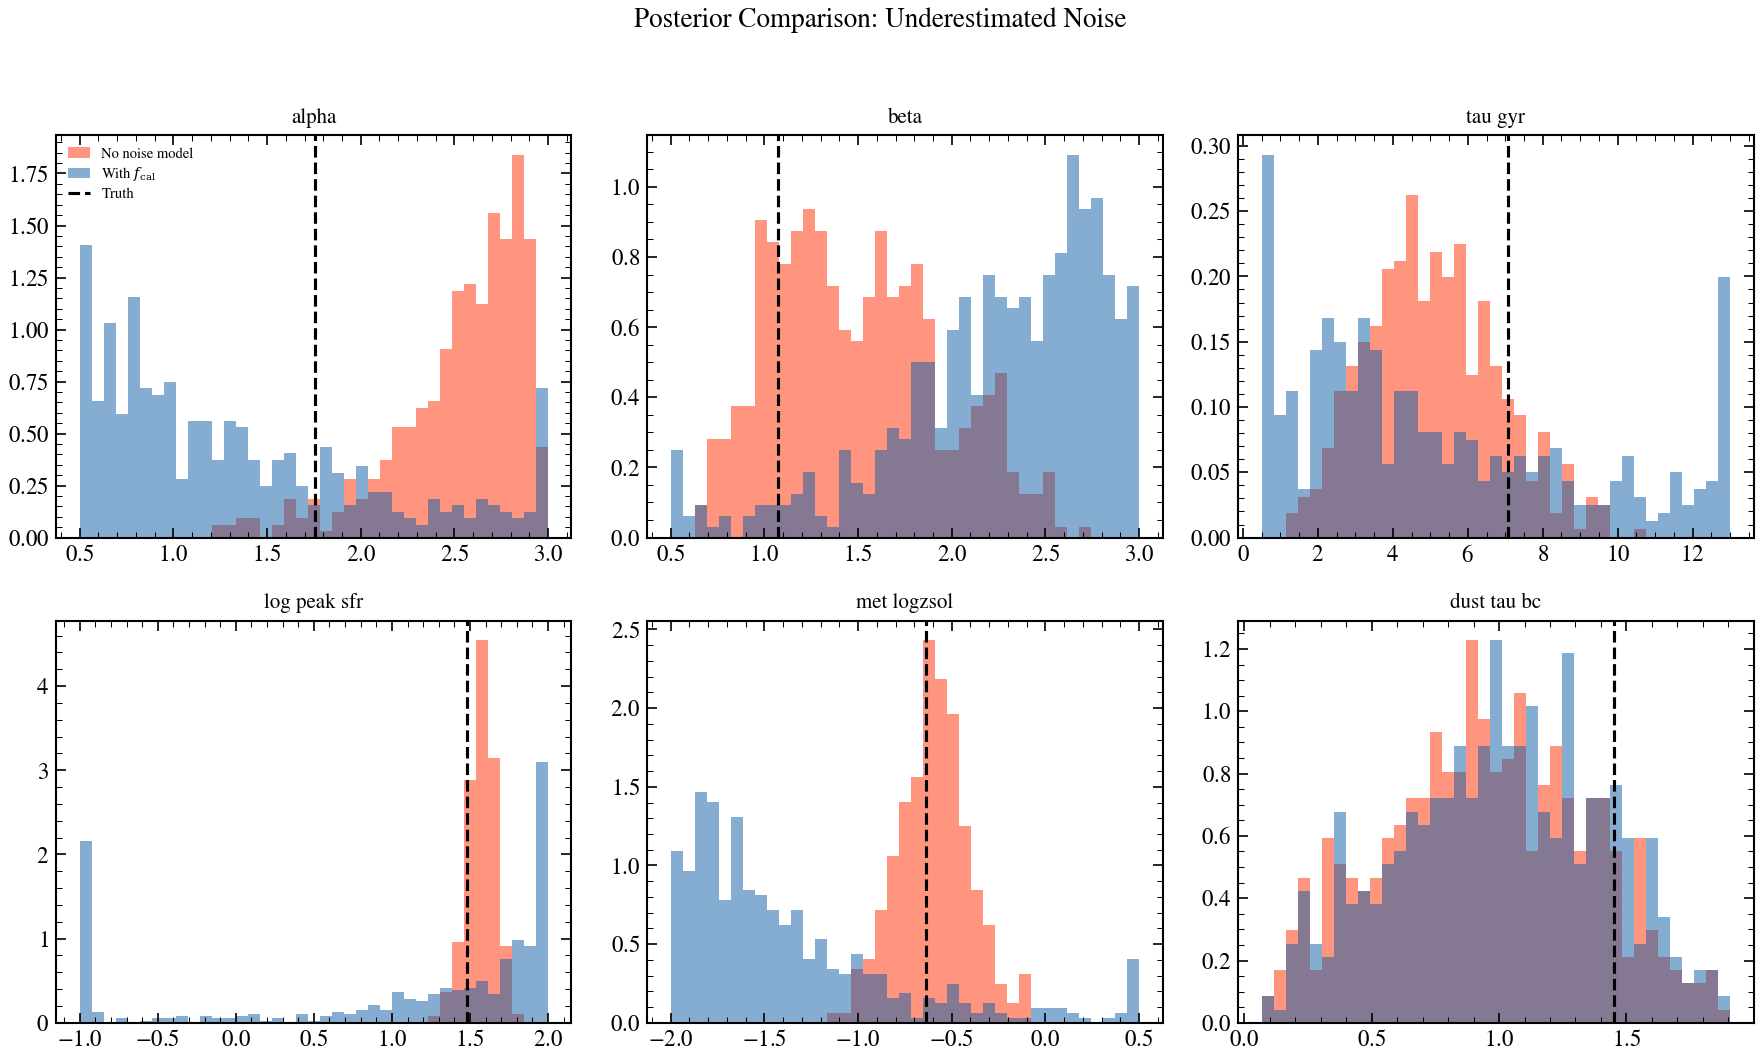

In [9]:
# Compare posterior widths
shared_params = [
    "sfh_dpl_alpha",
    "sfh_dpl_beta",
    "sfh_dpl_tau_gyr",
    "sfh_dpl_log_peak_sfr",
    "met_logzsol",
    "dust_tau_bc",
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, name in zip(axes.flat, shared_params):
    s_no = np.array(result_nonoise.samples[name])
    s_yes = np.array(result_noise.samples[name])
    true_val = float(true_params[name])

    bins = np.linspace(min(s_no.min(), s_yes.min()), max(s_no.max(), s_yes.max()), 40)
    ax.hist(s_no, bins=bins, alpha=0.5, density=True, color="C3", label="No noise model")
    ax.hist(s_yes, bins=bins, alpha=0.5, density=True, color="C0", label="With $f_\\mathrm{cal}$")
    ax.axvline(true_val, color="k", ls="--", lw=1.5, label="Truth")
    ax.set_title(name.replace("sfh_dpl_", "").replace("_", " "), fontsize=10)
    if ax == axes[0, 0]:
        ax.legend(fontsize=7)

plt.suptitle(
    "Posterior Comparison: Underestimated Noise",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.savefig("notebook_figures/11_noise_model_fig03.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Print width comparison
print(f"{'Parameter':<25} {'No noise (std)':<15} {'With f_cal (std)':<15} {'Ratio':<8}")
print("-" * 65)
for name in shared_params:
    std_no = float(np.std(np.array(result_nonoise.samples[name])))
    std_yes = float(np.std(np.array(result_noise.samples[name])))
    ratio = std_yes / std_no if std_no > 0 else float("inf")
    short = name.replace("sfh_dpl_", "").replace("_", " ")
    print(f"{short:<25} {std_no:<15.4f} {std_yes:<15.4f} {ratio:<8.1f}x")
print("\nNoise model posteriors are wider (more honest) when noise is underestimated.")

Parameter                 No noise (std)  With f_cal (std) Ratio   
-----------------------------------------------------------------
alpha                     0.3521          0.7108          2.0     x
beta                      0.4467          0.5607          1.3     x
tau gyr                   1.7440          3.7535          2.2     x
log peak sfr              0.0899          1.0905          12.1    x
met logzsol               0.1931          0.5766          3.0     x
dust tau bc               0.3994          0.4013          1.0     x

Noise model posteriors are wider (more honest) when noise is underestimated.


## 5. Student-t Outlier Robustness

Real data often contains catastrophic photometric errors: cosmic rays,
detector artifacts, deblending failures. The Gaussian likelihood assigns
**exponentially vanishing** probability to such outliers, allowing a
single bad data point to dominate the fit.

The **Student-t likelihood** with $\nu$ degrees of freedom has heavier
tails, naturally downweighting outliers:

$$E = \frac{\nu+1}{2} \sum_k \log\left(1 + \frac{r_k^2}{\nu}\right) + \sum_k \log \sigma_{\mathrm{eff},k}$$

For a 5$\sigma$ outlier ($r=5$):
- **Gaussian**: contributes $\frac{1}{2} \times 25 = 12.5$ to the energy
- **Student-t($\nu$=2)**: contributes $\frac{3}{2} \log(1 + 25/2) \approx 4.0$

The outlier is downweighted by ~3x, without any explicit masking.

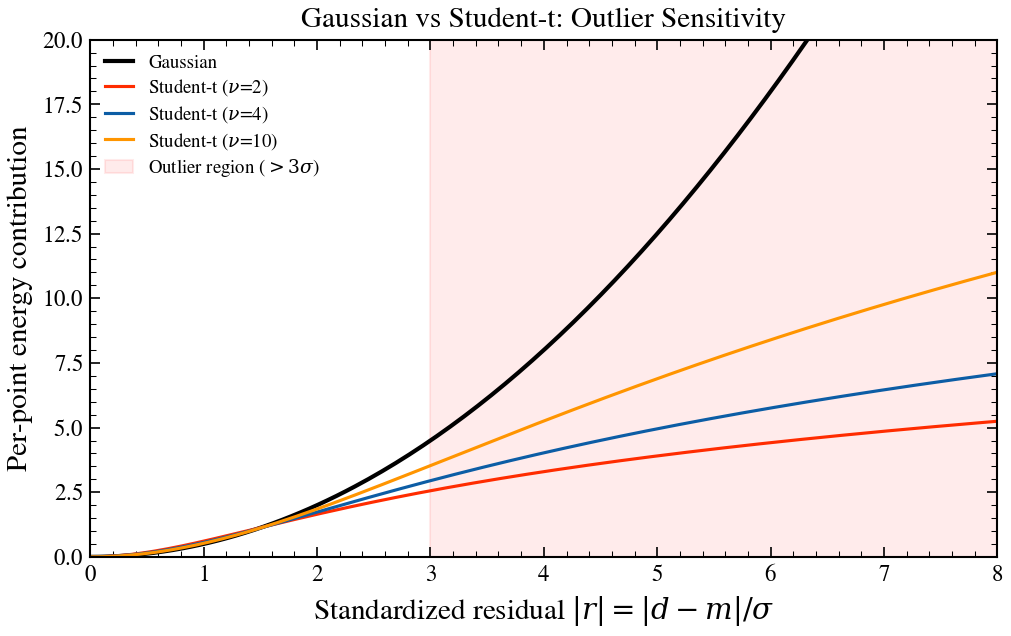

In [11]:
# --- Demonstrate outlier downweighting ---
r_values = np.linspace(0, 8, 200)

# Gaussian: 0.5 * r^2
e_gauss = 0.5 * r_values**2

# Student-t: (nu+1)/2 * log(1 + r^2/nu) for different nu
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(r_values, e_gauss, "k-", lw=2, label="Gaussian")

for nu, color in [(2, "C3"), (4, "C0"), (10, "C2")]:
    e_t = 0.5 * (nu + 1) * np.log(1 + r_values**2 / nu)
    ax.plot(r_values, e_t, "-", lw=1.5, color=color, label=f"Student-t ($\\nu$={nu})")

ax.axvspan(3, 8, alpha=0.08, color="red", label="Outlier region ($>3\\sigma$)")
ax.set_xlabel("Standardized residual $|r| = |d - m| / \\sigma$")
ax.set_ylabel("Per-point energy contribution")
ax.set_title("Gaussian vs Student-t: Outlier Sensitivity")
ax.legend(fontsize=9)
ax.set_xlim(0, 8)
ax.set_ylim(0, 20)
plt.tight_layout()
plt.savefig("notebook_figures/11_noise_model_fig04.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Fitting with an Outlier

We inject a catastrophic error in one band and compare Gaussian
vs Student-t($\nu$=2) fitting.

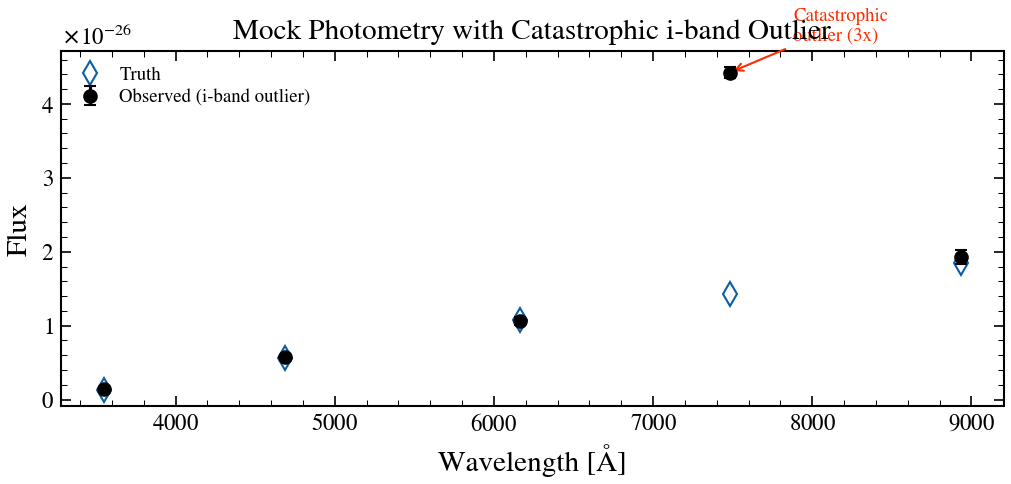

In [12]:
# Inject a catastrophic outlier in the i-band (index 3)
flux_outlier = mock.flux_obs.at[3].set(mock.flux_obs[3] * 3.0)  # 3x too bright

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.errorbar(
    SDSS_WAVE,
    flux_outlier,
    yerr=noise_correct,
    fmt="o",
    color="k",
    capsize=3,
    label="Observed (i-band outlier)",
    zorder=3,
)
ax.plot(SDSS_WAVE, mock.flux_true, "d", ms=8, mfc="none", color="C0", label="Truth")
ax.annotate(
    "Catastrophic\noutlier (3x)",
    xy=(SDSS_WAVE[3], flux_outlier[3]),
    xytext=(SDSS_WAVE[3] + 400, flux_outlier[3] * 1.1),
    arrowprops=dict(arrowstyle="->", color="C3"),
    fontsize=9,
    color="C3",
)
ax.set_xlabel("Wavelength [\u00c5]")
ax.set_ylabel("Flux")
ax.set_title("Mock Photometry with Catastrophic i-band Outlier")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("notebook_figures/11_noise_model_fig05.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Fit with Gaussian (no outlier protection)
spec_gauss = ParamSpec(
    sfh_dpl_alpha=Uniform(0.5, 3.0),
    sfh_dpl_beta=Uniform(0.5, 3.0),
    sfh_dpl_tau_gyr=Uniform(0.5, 13.0),
    sfh_dpl_log_peak_sfr=Uniform(-1.0, 2.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Fixed(0.3),
    dust_slope=Fixed(-0.7),
    noise_frac_cal=Uniform(0.01, 0.2),
    redshift=Fixed(0.1),
    mean_sfh_type="dpl",
)
model_gauss = Model(spec_gauss, ssp_data, filters=filters)

fitter_gauss = Fitter(model_gauss, flux_outlier, noise_correct)
result_gauss = fitter_gauss.run(
    "evi", n_iterations=30, n_samples=3, n_posterior_samples=500, key=jax.random.PRNGKey(2)
)
print(f"Gaussian fit: f_cal = {result_gauss.params.get('noise_frac_cal', 0):.3f}")

EVI (JIT): 7 params, 5 data points, 30 iterations, 3 samples/iter, 5 seeds


  Seed 1/5: H=1076.1, 12 iters
  Seed 2/5: H=3030.7, 12 iters
  Seed 3/5: H=2652.7, 28 iters
  Seed 4/5: H=4928.2, 18 iters
  Seed 5/5: H=13177.6, 13 iters
  Drawing 500 posterior samples (JIT CG)...


<local>/Projects/diffsed/src/diffsed/fitter.py:987: UserWarning: Seeds disagree: H = 4973.1 ± 4281.6 (CV=86%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_evi_jit(key=key, init_from=init_from, **kwargs)


  EVI (JIT) complete in 5.2s, 12/30 iterations, 500 posterior samples
Gaussian fit: f_cal = 0.184


<local>/Projects/diffsed/src/diffsed/fitter.py:987: UserWarning: Poor fit: chi2/dof=383.9 (expected ~1)
  return self._run_evi_jit(key=key, init_from=init_from, **kwargs)
<local>/Projects/diffsed/src/diffsed/fitter.py:987: UserWarning: Parameters near bounds: sfh_dpl_log_peak_sfr. Consider widening the prior.
  return self._run_evi_jit(key=key, init_from=init_from, **kwargs)


In [14]:
# Fit with Student-t (outlier robust)
spec_student = ParamSpec(
    sfh_dpl_alpha=Uniform(0.5, 3.0),
    sfh_dpl_beta=Uniform(0.5, 3.0),
    sfh_dpl_tau_gyr=Uniform(0.5, 13.0),
    sfh_dpl_log_peak_sfr=Uniform(-1.0, 2.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Fixed(0.3),
    dust_slope=Fixed(-0.7),
    noise_frac_cal=Uniform(0.01, 0.2),
    noise_dof=Fixed(2.0),
    redshift=Fixed(0.1),
    mean_sfh_type="dpl",
)
model_student = Model(spec_student, ssp_data, filters=filters)

fitter_student = Fitter(model_student, flux_outlier, noise_correct)
result_student = fitter_student.run(
    "evi", n_iterations=30, n_samples=3, n_posterior_samples=500, key=jax.random.PRNGKey(2)
)
print(f"Student-t fit: f_cal = {result_student.params.get('noise_frac_cal', 0):.3f}")

EVI (JIT): 7 params, 5 data points, 30 iterations, 3 samples/iter, 5 seeds


  Seed 1/5: H=2565.5, 6 iters
  Seed 2/5: H=702.8, 16 iters
  Seed 3/5: H=2141.7, 6 iters
  Seed 4/5: H=2137.6, 9 iters
  Seed 5/5: H=2202.7, 11 iters
  Drawing 500 posterior samples (JIT CG)...


<local>/Projects/diffsed/src/diffsed/fitter.py:987: UserWarning: Seeds disagree: H = 1950.1 ± 643.5 (CV=33%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_evi_jit(key=key, init_from=init_from, **kwargs)


  EVI (JIT) complete in 5.3s, 16/30 iterations, 500 posterior samples
Student-t fit: f_cal = 0.134


<local>/Projects/diffsed/src/diffsed/fitter.py:987: UserWarning: Poor fit: chi2/dof=329.3 (expected ~1)
  return self._run_evi_jit(key=key, init_from=init_from, **kwargs)


### Compare SED fits

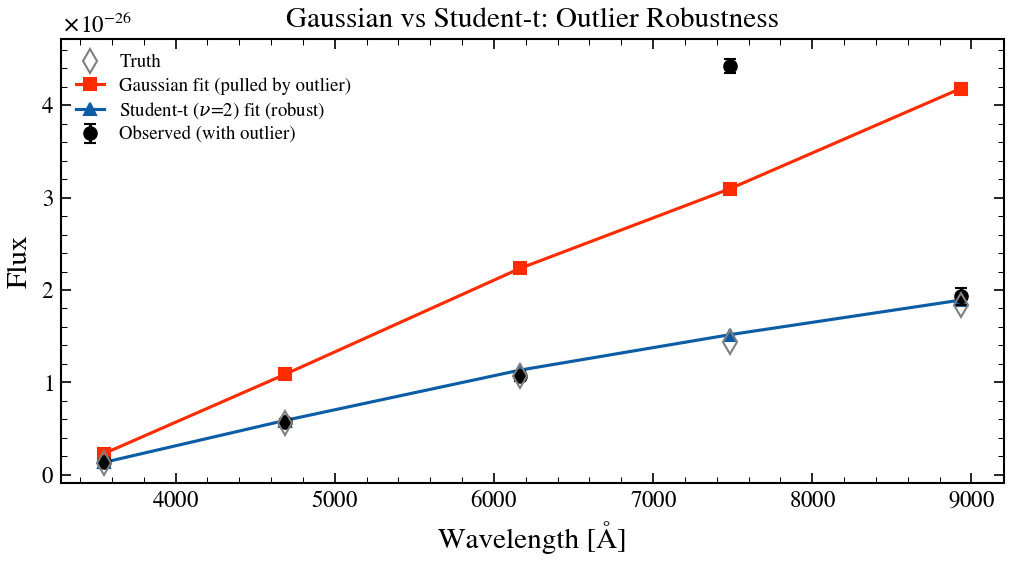

In [15]:
pred_gauss = model_gauss.predict_photometry(result_gauss.params)
pred_student = model_student.predict_photometry(result_student.params)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    SDSS_WAVE,
    flux_outlier,
    yerr=noise_correct,
    fmt="o",
    color="k",
    capsize=3,
    label="Observed (with outlier)",
    zorder=3,
)
ax.plot(SDSS_WAVE, mock.flux_true, "d", ms=8, mfc="none", color="grey", label="Truth", zorder=4)
ax.plot(SDSS_WAVE, pred_gauss, "s-", ms=6, color="C3", label="Gaussian fit (pulled by outlier)")
ax.plot(SDSS_WAVE, pred_student, "^-", ms=6, color="C0", label="Student-t ($\\nu$=2) fit (robust)")

ax.set_xlabel("Wavelength [\u00c5]")
ax.set_ylabel("Flux")
ax.set_title("Gaussian vs Student-t: Outlier Robustness")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("notebook_figures/11_noise_model_fig06.png", dpi=150, bbox_inches="tight")
plt.show()

### Compare parameter recovery

In [16]:
print(f"{'Parameter':<25} {'Truth':<10} {'Gaussian':<12} {'Student-t':<12} {'Winner':<8}")
print("-" * 70)
for name in shared_params:
    truth = float(true_params[name])
    g_val = float(result_gauss.params[name])
    s_val = float(result_student.params[name])
    g_err = abs(g_val - truth)
    s_err = abs(s_val - truth)
    winner = "Student-t" if s_err < g_err else "Gaussian"
    short = name.replace("sfh_dpl_", "").replace("_", " ")
    print(f"{short:<25} {truth:<10.3f} {g_val:<12.3f} {s_val:<12.3f} {winner:<8}")

Parameter                 Truth      Gaussian     Student-t    Winner  
----------------------------------------------------------------------
alpha                     1.757      1.640        1.821        Student-t
beta                      1.072      1.449        1.578        Gaussian
tau gyr                   7.085      8.825        6.838        Student-t
log peak sfr              1.480      1.948        1.563        Student-t
met logzsol               -0.635     -0.449       -0.845       Gaussian
dust tau bc               1.451      0.987        0.988        Student-t


## 7. Energy Comparison: Gaussian vs Student-t

To see how the two likelihoods handle the outlier differently, we
compare the per-band energy contributions.

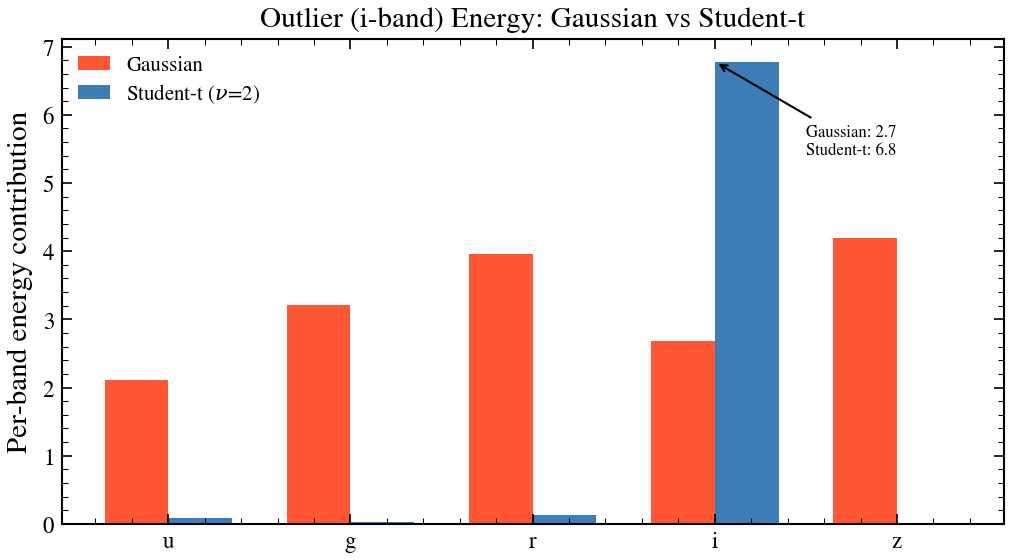

In [17]:
sigma_eff_g = compute_effective_noise(
    noise_correct, pred_gauss, jnp.array(result_gauss.params.get("noise_frac_cal", 0.0))
)
sigma_eff_s = compute_effective_noise(
    noise_correct, pred_student, jnp.array(result_student.params.get("noise_frac_cal", 0.0))
)

r_gauss = (flux_outlier - pred_gauss) / sigma_eff_g
r_student = (flux_outlier - pred_student) / sigma_eff_s

e_per_band_gauss = 0.5 * np.array(r_gauss) ** 2
e_per_band_student = 0.5 * 3.0 * np.log(1.0 + np.array(r_student) ** 2 / 2.0)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(5)
width = 0.35
bars1 = ax.bar(x - width / 2, e_per_band_gauss, width, color="C3", alpha=0.8, label="Gaussian")
bars2 = ax.bar(
    x + width / 2, e_per_band_student, width, color="C0", alpha=0.8, label="Student-t ($\\nu$=2)"
)
ax.set_xticks(x)
ax.set_xticklabels(BAND_NAMES)
ax.set_ylabel("Per-band energy contribution")
ax.set_title("Outlier (i-band) Energy: Gaussian vs Student-t")
ax.legend()

# Annotate the outlier band
max_e = max(e_per_band_gauss[3], e_per_band_student[3])
ax.annotate(
    f"Gaussian: {e_per_band_gauss[3]:.1f}\nStudent-t: {e_per_band_student[3]:.1f}",
    xy=(3, max_e),
    xytext=(3.5, max_e * 0.8),
    fontsize=8,
    color="k",
    arrowprops=dict(arrowstyle="->", color="k"),
)

plt.tight_layout()
plt.savefig("notebook_figures/11_noise_model_fig07.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Feature | Parameter | Effect |
|---------|-----------|--------|
| **Calibration floor** | `noise_frac_cal=Uniform(0.01, 0.2)` | Adds fractional uncertainty in quadrature; log-det prevents $\sigma\to\infty$ |
| **Outlier robustness** | `noise_dof=Fixed(2.0)` | Student-t heavy tails downweight catastrophic points by ~3x |
| **Default (off)** | No noise params | Standard fixed-noise Gaussian --- identical to previous behavior |

### When to use what

1. **Always enable `noise_frac_cal`** when fitting real data. Photometric
   calibration uncertainties are ubiquitous (1--15%).
2. **Add `noise_dof=Fixed(2.0)`** for survey data with known artifacts
   (cosmic rays, deblending, satellite trails).
3. **Skip both** only for idealized mock recovery tests where noise is
   perfectly known.

### Implementation notes

- Uses NIFTy's `VariableCovarianceGaussian` and
  `VariableCovarianceStudentT` --- the noise model is native to the
  inference framework, not a post-hoc correction.
- `noise_frac_cal` is part of the standardized latent vector
  $\boldsymbol{\xi}$ and jointly inferred with all other parameters.
- The GGN metric for the variable-noise likelihood is analytically
  derived, ensuring the JIT EVI engine works correctly.
- Backward compatible: default `Fixed(0.0)` gives identical behavior
  to the code before the noise model was added.